# 1. Project 2: R&D Investment Under National Uncertainty

### DATA 201 Spring 2026
### Name: Raul Miranda
### Date: April 30, 2026


## 2. Short Introduction

For governments to consider future investment policies, it is important to understand the correlations between individual wealth (GDP/capita), human development features such a life expectancy, education and health expenditure, and technological development features such as R&D expenditure. R&D is a key driver of innovation, productivity, and competitiveness. However, national sentiment is also an important variable that may influence decisions. In this project we use the world uncertainty index (WUI) as a potential predictor.

The basic questions pursued here are: **does national and individual wealth drive technology (GDP vs. R&D expenditure) and human development (GDP vs. life expectancy, education and health expenditure)? Does uncertainty affect R&D investment? Do structural features such as region and income group influence those relationships?**


### Datasets

**World Uncertainty Index** http://worlduncertaintyindex.com/data/, downloaded to project folder as WUI_data.xlsx. The second tab: T2, filtered for the 1995-2024 period was downloaded to project folder as wuncertindex.csv.

The World Uncertainty Index is a measure that tracks uncertainty across the globe by sentiment analysis of country reports of the Economist Intelligence Unit of the International Monetary Fund. The index is available for 143 countries and published quarterly since the 1950s. Score: (positive words-negative words)/total words x 1000.

**World Bank - Development Indicators** https://databank.worldbank.org/source/world-development-indicators - selected: time period: 1995-2024, countries shown below, and these 6 indicator codes:

"NY.GDP.PCAP.CD":    "gdp_per_capita_usd" - GDP/capita
"NY.GDP.PCAP.KD.ZG": "gdp_pc_growth_pct"  - growth of %GDP/capita
"SP.DYN.LE00.IN":    "life_expectancy"    - life expectancy
"SE.XPD.TOTL.GD.ZS": "education_spend_pct_gdp" - education, %GDP
"SH.XPD.CHEX.GD.ZS": "health_spend_pct_gdp" - health, %GDP
"GB.XPD.RSDV.GD.ZS": "rd_spend_pct_gdp"   - R&D, %GDP

Countries are uniquely identified by their ISO-3 code.

World Bank also labels countries by:

Regions: Europe, North America, Latin America, Asia-Pacific, Middle-East, Africa

Income status: High, Upper-Middle, Lower-Middle, Low

The selection was downloaded to the project folder as: worldbank.csv.
Both worldbank.csv and wuncertindex.csv were merged by iso-3 code and year, to yield wuiwbi.csv, used as input for this project.

### Data limitations. Population of interest. Bias concerns.

To answer the questions mentioned at the top, we used the World Uncertainty Index (WUI) and the selected World Bank Indicators (WBI). A thorough study could certainly include other characteristics, such as patents for technology development, World Sentiment Index, etc.

Finding a good intersection of data (WUI and WBI) without too many NaN forced us to restrict the years to **1995-2024**, and the countries to **52 nations**. That eliminated the Low income status countries. Thus the conclusions from this analysis is biased by the lack of data from certain nations.

Country-ISO3 selected: "USA", "GBR", "FRA", "DEU", "ITA", "ESP", "NLD", "BEL", "SWE", "NOR", "DNK", "FIN", "AUT", "CHE", "PRT", "IRL", "CAN", "AUS", "NZL", "JPN", "KOR", "ISR", "SAU", "ARE", "QAT", "KWT", "CHN", "BRA", "MEX", "ARG", "ZAF", "TUR", "POL", "HUN", "CZE", "ROU", "MYS", "THA", "COL", "PER", "IND", "IDN", "PAK", "EGY", "MAR", "NGA", "KEN", "UKR", "RUS", "IRQ", "IRN", "GRC"

## 3. Libraries

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import (mean_squared_error, r2_score,
                              accuracy_score, roc_auc_score,
                              roc_curve, confusion_matrix, ConfusionMatrixDisplay)

# Set the plot themes and style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5),
                     'axes.titlesize': 13, 'axes.labelsize': 11})

## 4. Load the Data

The combined WUI and WBI datasets merged by country_iso3 code and year were saved as "wuiwbi.csv", which is loaded below.


In [91]:
# load wuiwbi.csv and show its shape and columns 

wuiwbi = pd.read_csv("wuiwbi.csv")
print(f"WUIWBI shape (rows, columns): {wuiwbi.shape}")
print("\nColumn/variable names:")
for c in wuiwbi.columns:
    print(" ", c)
print("""\nCategorical variables: country_iso3, region, income_group
Numerical variables: the other variables, in units of years, US Dollar, 
percent (pct), or dimensionless for wui, wui_volatility: a three-quarter weighted average of wui
""")

WUIWBI shape (rows, columns): (1560, 11)

Column/variable names:
  country_iso3
  year
  region
  income_group
  gdp_per_capita_usd
  life_expectancy
  health_spend_pct_gdp
  education_spend_pct_gdp
  rd_spend_pct_gdp
  wui
  wui_volatility

Categorical variables: country_iso3, region, income_group
Numerical variables: the other variables, in units of years, US Dollar, 
percent (pct), or dimensionless for wui, wui_volatility: a three-quarter weighted average of wui



## 5. Dataset Structure

Each **row** corresponds to a country in a specific year.  
The dataset goes from 1995 until 2024 for 52 countries; restricted from the onset to have very few NaNs (30 for education_spend_pct_gdp).


In [92]:
print(f"Rows: {wuiwbi.shape[0]:,}")   # rows
print(f"Columns: {wuiwbi.shape[1]:,}")   # columns
print(f"Unique countries: {wuiwbi['country_iso3'].nunique()}")
print(f"Unique region: {wuiwbi['region'].unique()}")
print(f"Unique income_group: {wuiwbi['income_group'].unique()}")
print(f"Year range: {wuiwbi['year'].min()} - {wuiwbi['year'].max()}")

Rows: 1,560
Columns: 11
Unique countries: 52
Unique region: ['Middle East' 'Latin America' 'Asia-Pacific' 'Europe' 'North America' 'Africa']
Unique income_group: ['High' 'Upper-middle' 'Lower-middle']
Year range: 1995 - 2024


## 6. Data Cleaning

Before analysis we impute NaNs with mean of each column.

In [93]:
print(wuiwbi.head())
print(wuiwbi.info())
print(wuiwbi.isna().sum())  # how many NaNs in each column
wuiwbi = wuiwbi.fillna(wuiwbi.median(numeric_only=True)) # impute NaNs
print(wuiwbi.isna().sum()) # check if all the unmasked NaNs were removed

  country_iso3  year       region income_group  gdp_per_capita_usd  life_expectancy  health_spend_pct_gdp  \
0          ARE  1995  Middle East         High        27003.200681           71.392              2.395045   
1          ARE  1996  Middle East         High        28323.165087           71.820              2.395045   
2          ARE  1997  Middle East         High        27982.795704           72.559              2.395045   
3          ARE  1998  Middle East         High        24889.426919           73.660              2.395045   
4          ARE  1999  Middle East         High        25855.860505           74.982              2.395045   

   education_spend_pct_gdp  rd_spend_pct_gdp       wui  wui_volatility  
0                   3.8602           0.47252  0.050293        0.060586  
1                   3.8602           0.47252  0.000000        0.000000  
2                   3.8602           0.47252  0.104403        0.076275  
3                   3.8602           0.47252  0.30301

In [94]:
# Define new variables to be used in the statistical analysis section

# Log GDP/capita

wuiwbi['log_gdp'] = np.log1p(wuiwbi['gdp_per_capita_usd'])

# Quadratic term for log_gdp

wuiwbi['log_gdp_sq'] = wuiwbi['log_gdp']**2

# Interaction term for log_gdp and wui

wuiwbi['log_gdp_wui'] = wuiwbi['log_gdp'] * wuiwbi['wui']

# Convert categorical variables (region, income group) to dummies; don't drop reference levels yet

wuiwbi = pd.get_dummies(wuiwbi, columns=['region', 'income_group'], drop_first=False)  #make 6+3 dummies


## 7. Exploratory Data Analysis

### Visualization

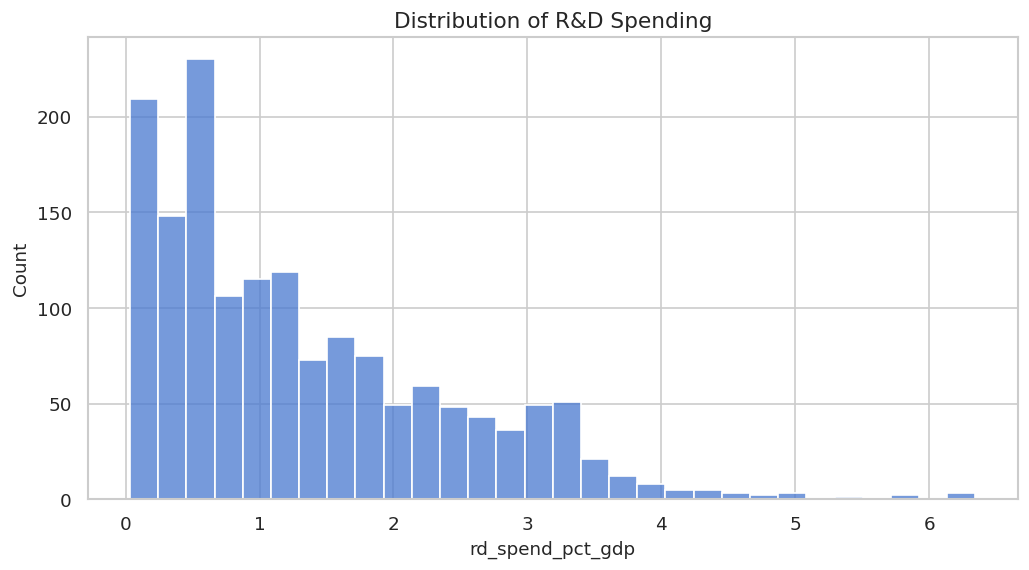

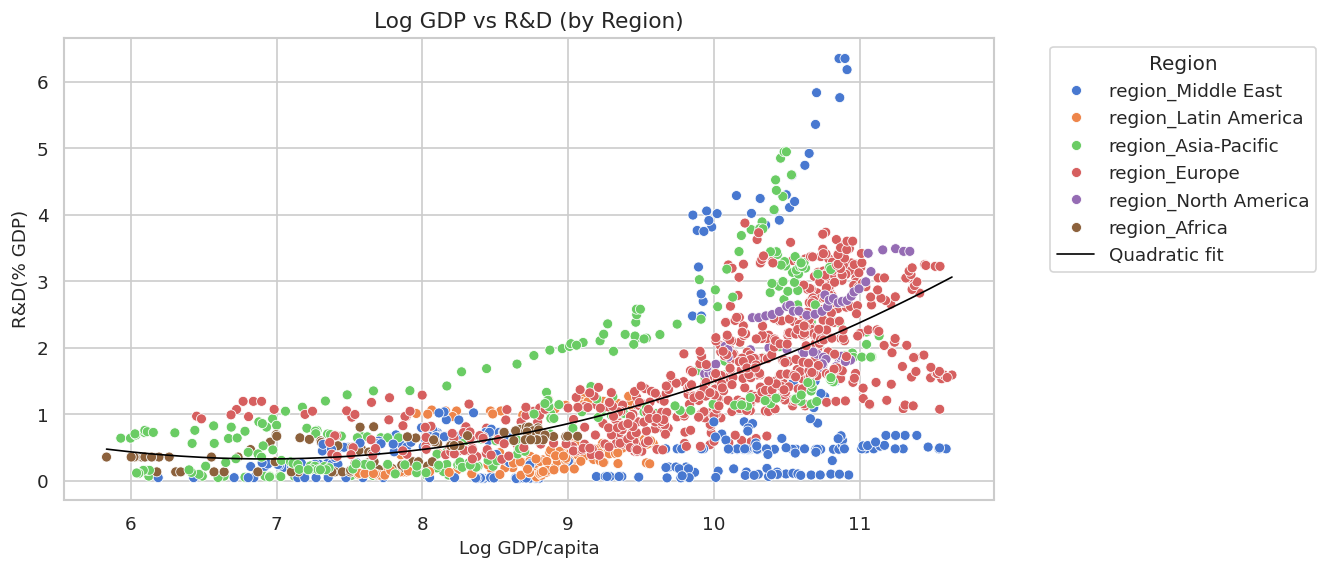

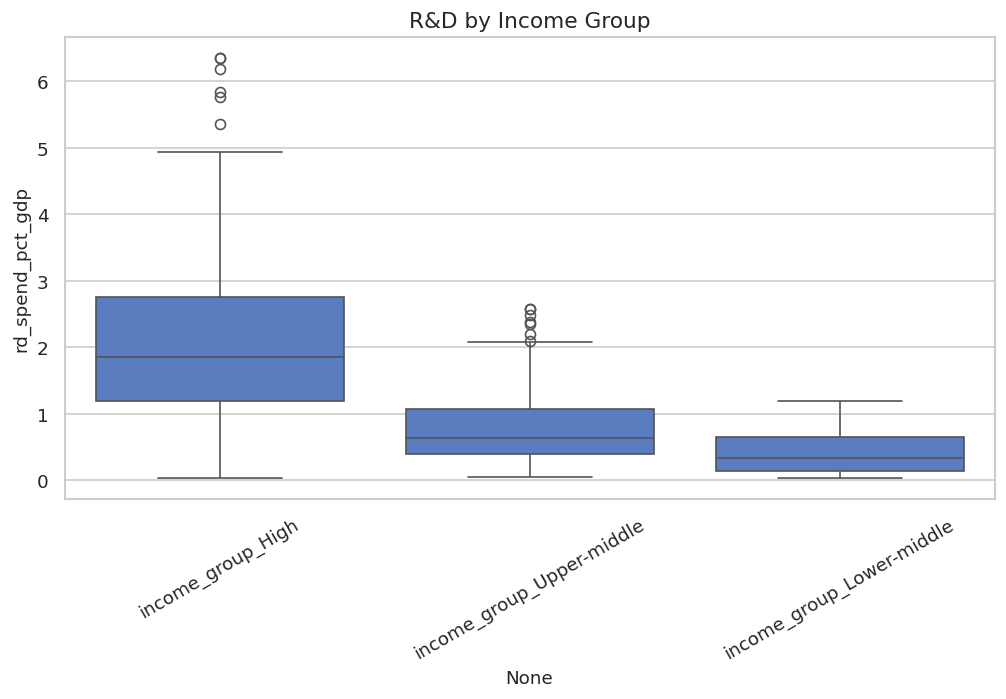

In [95]:
# Histogram
sns.histplot(wuiwbi['rd_spend_pct_gdp'], bins=30)
plt.title('Distribution of R&D Spending')
plt.show()

# Create helper columns for labels
region_labels = wuiwbi.filter(like='region_').idxmax(axis=1)
income_labels = wuiwbi.filter(like='income_group_').idxmax(axis=1)

# Scatter GDP vs R&D (colored by region)
sns.scatterplot(x='log_gdp', y='rd_spend_pct_gdp', hue=region_labels, data=wuiwbi)
z = np.polyfit(wuiwbi['log_gdp'], wuiwbi['rd_spend_pct_gdp'], 2)  # quadratic fit line
p = np.poly1d(z)

x_sorted = np.sort(wuiwbi['log_gdp'])
plt.plot(x_sorted, p(x_sorted), linewidth=1, color='black', label='Quadratic fit')

plt.title('Log GDP vs R&D (by Region)')
plt.xlabel('Log GDP/capita')
plt.ylabel('R&D(% GDP)')
plt.legend(title='Region', bbox_to_anchor=(1.05,1))
plt.show()

# Boxplot by income group
sns.boxplot(x=income_labels, y='rd_spend_pct_gdp', data=wuiwbi)
plt.xticks(rotation=30)
plt.title('R&D by Income Group')
plt.show()

Initial exploration of the data reveals that R&D expenditure is right-skewed, with most countries spending relatively little and a small number investing heavily.

Scatterplots show a positive but nonlinear relationship between GDP per capita and R&D expenditure, suggesting diminishing returns at higher income levels.

When visualizing by region, countries cluster into distinct groups, indicating structural differences across geographic areas. Boxplots by income group show that high-income countries consistently invest more in R&D than lower-income countries.

These patterns suggest that both economic capacity and structural characteristics play an important role in explaining R&D investment.

### Train/Test Split

The dataset is split into training (80%) and testing (20%) sets. This approach ensures that models are evaluated on unseen data, providing a more reliable assessment of predictive performance. We'll setup two models, one without the region and income group, and the other including those categorical variables.

In [96]:
# now drop the reference dummy variables: region_Africa and income_group_Lower-middle
wuiwbi.drop(columns=['region_Africa', 'income_group_Lower-middle'], inplace=True) 

# identify the 5+2 categorical variables remaining
cat_vars = [col for col in wuiwbi.columns if 'region_' in col or 'income_group_' in col]

# basic features without categorical dummies
features_basic = ['log_gdp', 'wui', 'life_expectancy', 'education_spend_pct_gdp', 'health_spend_pct_gdp'] 

# all features including categorical dummies
features_cat = features_basic + cat_vars

X = wuiwbi[features_basic]
y = wuiwbi['rd_spend_pct_gdp']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

### Model 1: Linear Regression without region and income group included

In [97]:
model1 = LinearRegression()
model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

rmse1 = np.sqrt(mean_squared_error(y_test, y_pred1))
r2_1 = r2_score(y_test, y_pred1)

print("Model 1 - Linear")
print("RMSE:", rmse1)
print("R^2:", r2_1)

coeffs1 = pd.DataFrame({ 'Variable': X.columns,'Coefficient': model1.coef_})
coeffs1.loc[len(coeffs1)] = ['Intercept', model1.intercept_]
print("\nModel 1 Coefficients:")
print(coeffs1)

Model 1 - Linear
RMSE: 0.7804119606791136
R^2: 0.506988636184072

Model 1 Coefficients:
                  Variable  Coefficient
0                  log_gdp     0.211815
1                      wui    -0.334377
2          life_expectancy     0.016379
3  education_spend_pct_gdp     0.053118
4     health_spend_pct_gdp     0.150732
5                Intercept    -3.144666


A basic linear regression model was estimated using log GDP per capita, uncertainty (WUI), and human development indicators. The results indicate that these variables explain about half of the variation in R&D expenditure. A negative coefficient for a variable indicates that a unit increase of the variable causes a decrease of R&D_spend_pct_gdp equal to the coefficient value. E.g., increasing uncertainty (wui) by a unit decreases R&D_spend_pct_gdp by 0.334377.

### Model 1b: Linear regression including all features, including region and income group

In [98]:
X = wuiwbi[features_cat]   # all features
y = wuiwbi['rd_spend_pct_gdp']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

model1b = LinearRegression()
model1b.fit(X_train, y_train)

y_pred1b = model1b.predict(X_test)

rmse1b = np.sqrt(mean_squared_error(y_test, y_pred1b))
r2_1b = r2_score(y_test, y_pred1b)

print("Model 1b - Linear with categorical features included")
print("RMSE:", rmse1b)
print("R^2:", r2_1b)

coeffs1b = pd.DataFrame({ 'Variable': X.columns,'Coefficient': model1b.coef_})
coeffs1b.loc[len(coeffs1b)] = ['Intercept', model1b.intercept_]
print("\nModel 1b Coefficients:")
print(coeffs1b)


Model 1b - Linear with categorical features included
RMSE: 0.6884611649294636
R^2: 0.6163210340867642

Model 1b Coefficients:
                     Variable  Coefficient
0                     log_gdp     0.185576
1                         wui    -0.024107
2             life_expectancy     0.011653
3     education_spend_pct_gdp     0.070342
4        health_spend_pct_gdp     0.176470
5         region_Asia-Pacific     0.405489
6               region_Europe    -0.126032
7        region_Latin America    -0.660679
8          region_Middle East    -0.111492
9        region_North America    -0.431555
10          income_group_High     0.081042
11  income_group_Upper-middle    -0.068378
12                  Intercept    -2.799833


Including categorical variables for region and income group significantly improved model performance:

R^2 increased to ≈ 0.62
RMSE decreased to ≈ 0.69

This indicates that structural differences across countries play a major role in explaining R&D expenditure.

### Model 2: Polynomial regression: quadratic in log GDP

In [99]:
features_poly = ['log_gdp', 'log_gdp_sq', 'wui', 'life_expectancy', 'education_spend_pct_gdp', 'health_spend_pct_gdp'] + cat_vars

X_poly = wuiwbi[features_poly]
y_poly = wuiwbi['rd_spend_pct_gdp']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_poly, y_poly, test_size=0.2, random_state=1)

model2 = LinearRegression()
model2.fit(X_train_p, y_train_p)

y_pred2 = model2.predict(X_test_p)

rmse2 = np.sqrt(mean_squared_error(y_test_p, y_pred2))
r2_2 = r2_score(y_test_p, y_pred2)

print("\nModel 2 - Polynomial")
print("RMSE:", rmse2)
print("R^2:", r2_2)

coeffs2 = pd.DataFrame({ 'Variable': X_poly.columns,'Coefficient': model2.coef_})
coeffs2.loc[len(coeffs2)] = ['Intercept', model2.intercept_]
print("\nModel 2 Coefficients:")
print(coeffs2)


Model 2 - Polynomial
RMSE: 0.6898788858754776
R^2: 0.6147392171264034

Model 2 Coefficients:
                     Variable  Coefficient
0                     log_gdp    -1.144941
1                  log_gdp_sq     0.075022
2                         wui    -0.047078
3             life_expectancy     0.012470
4     education_spend_pct_gdp     0.068113
5        health_spend_pct_gdp     0.172895
6         region_Asia-Pacific     0.398274
7               region_Europe    -0.111103
8        region_Latin America    -0.619190
9          region_Middle East    -0.062759
10       region_North America    -0.429600
11          income_group_High     0.070199
12  income_group_Upper-middle     0.089063
13                  Intercept     2.858952


To account for the observed nonlinear relationship between GDP and R&D, a quadratic term in log GDP was introduced.

The model remained with similar accuracy.

R^2 remained at 0.62
RMSE remained at 0.69

The results confirm diminishing returns to income in R&D investment.

### Model 3: Interaction of log GDP and WUI

In [100]:
features_inter = ['log_gdp', 'wui', 'log_gdp_wui', 'life_expectancy', 'education_spend_pct_gdp', 'health_spend_pct_gdp'] + cat_vars

X_inter = wuiwbi[features_inter]
y_inter = wuiwbi['rd_spend_pct_gdp']

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X_inter, y_inter, test_size=0.2, random_state=1)

model3 = LinearRegression()
model3.fit(X_train_i, y_train_i)

y_pred3 = model3.predict(X_test_i)

rmse3 = np.sqrt(mean_squared_error(y_test_i, y_pred3))
r2_3 = r2_score(y_test_i, y_pred3)

print("\nModel 3 - Interaction")
print("RMSE:", rmse3)
print("R^2:", r2_3)

coeffs3 = pd.DataFrame({'Variable': X_inter.columns, 'Coefficient': model3.coef_})
coeffs3.loc[len(coeffs3)] = ['Intercept', model3.intercept_]
print("\nModel 3 Coefficients:")
print(coeffs3)



Model 3 - Interaction
RMSE: 0.6887660717949343
R^2: 0.6159811100289887

Model 3 Coefficients:
                     Variable  Coefficient
0                     log_gdp     0.161583
1                         wui    -1.352104
2                 log_gdp_wui     0.140395
3             life_expectancy     0.012262
4     education_spend_pct_gdp     0.071533
5        health_spend_pct_gdp     0.173529
6         region_Asia-Pacific     0.360571
7               region_Europe    -0.168104
8        region_Latin America    -0.686707
9          region_Middle East    -0.160606
10       region_North America    -0.462253
11          income_group_High     0.085348
12  income_group_Upper-middle    -0.066536
13                  Intercept    -2.567572


An interaction term between GDP and uncertainty was added to test whether uncertainty affects countries differently depending on income level.

However, this model did not significantly improve performance relative to the basic or polynomial model, suggesting that the interaction effect is limited.

This is the comparison between all those models:

In [101]:
results = pd.DataFrame({'Model': ['Linear', 'Linear with Categorical', 'Polynomial', 'Interaction'],
    'RMSE': [rmse1, rmse1b, rmse2, rmse3],'R2': [r2_1, r2_1b, r2_2, r2_3]})

print("\nModel Comparison:")
print(results)


Model Comparison:
                     Model      RMSE        R2
0                   Linear  0.780412  0.506989
1  Linear with Categorical  0.688461  0.616321
2               Polynomial  0.689879  0.614739
3              Interaction  0.688766  0.615981


### Logistic regression and classification of countries depending on R&D investment


Logistic Regression Coefficients and Odd Ratios:
                     Variable  Coefficient  Odds Ratio
5         region_Asia-Pacific     2.746470   15.587509
9        region_North America     1.309094    3.702817
0                     log_gdp     1.301490    3.674768
6               region_Europe     0.899455    2.458262
11  income_group_Upper-middle     0.652563    1.920458
4        health_spend_pct_gdp     0.482596    1.620275
8          region_Middle East    -0.465566    0.627780
7        region_Latin America    -0.455150    0.634353
3     education_spend_pct_gdp     0.191860    1.211501
10          income_group_High     0.091633    1.095962
2             life_expectancy     0.059409    1.061209
1                         wui    -0.011484    0.988582


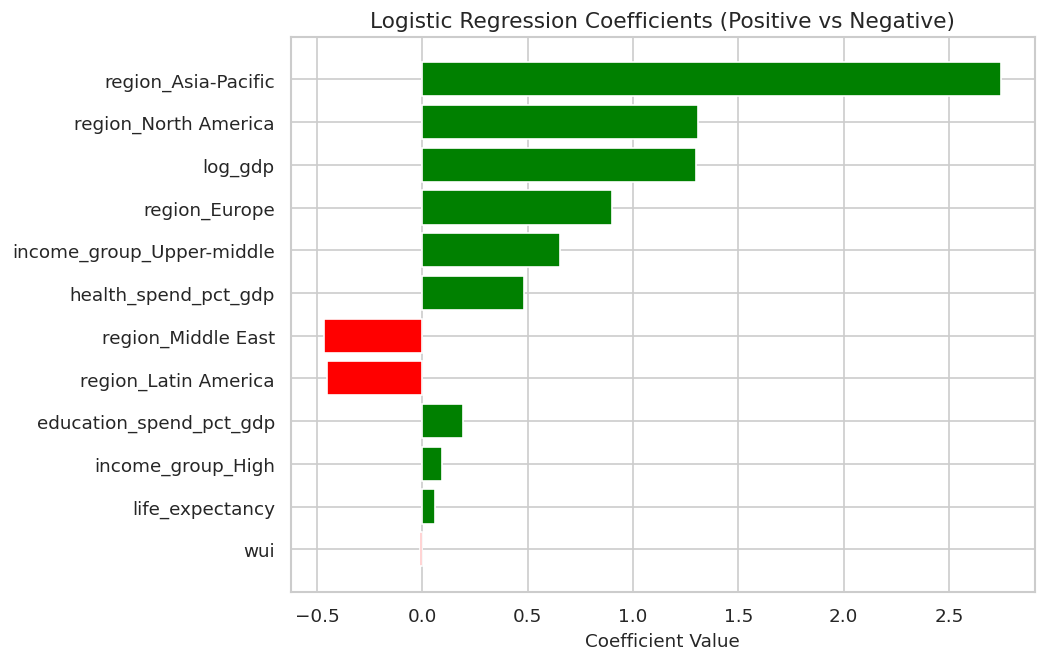


Logistic Regression Accuracy: 0.8910256410256411
[[141  16]
 [ 18 137]]


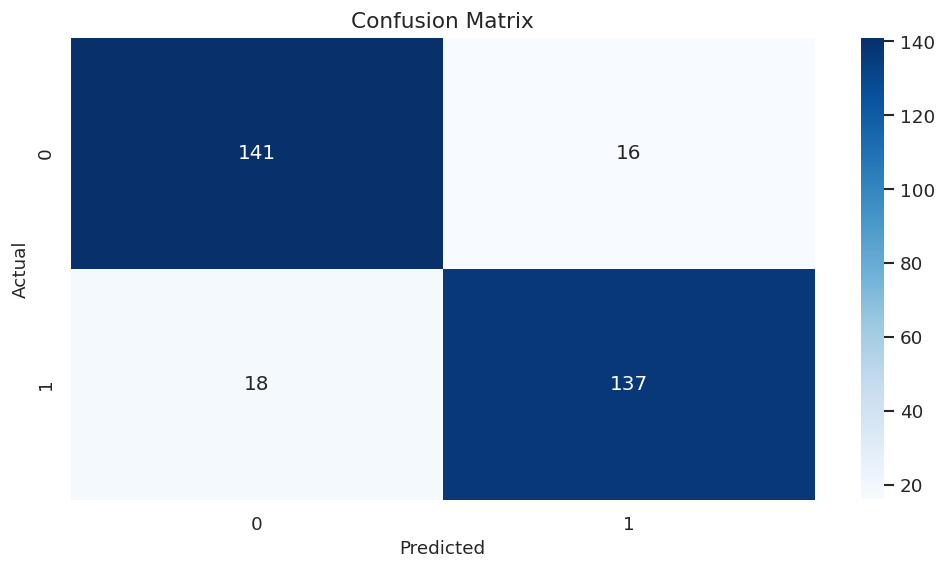

ROC-AUC: 0.9612903225806452


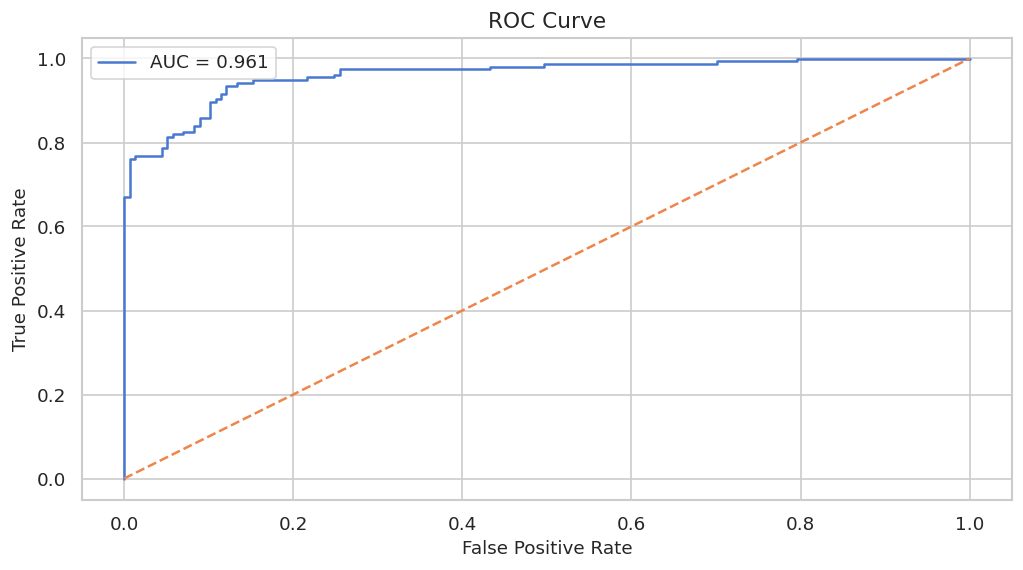

In [102]:
# Create binary variable;  define high_rd: rd_spend > median rd_spend

wuiwbi['high_rd'] = (wuiwbi['rd_spend_pct_gdp'] > wuiwbi['rd_spend_pct_gdp'].median()).astype(int)
X_class = wuiwbi[features_cat]
y_class = wuiwbi['high_rd']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.2, random_state=1)

clf = LogisticRegression(max_iter=1000)   # do the logistic regression
clf.fit(X_train_c, y_train_c)             # and classification

logit_coeffs = pd.DataFrame({'Variable': X_class.columns, 'Coefficient': clf.coef_[0]})

logit_coeffs = logit_coeffs.sort_values(by='Coefficient', key=abs, ascending=False) # sort by importance
logit_coeffs['Odds Ratio'] = np.exp(logit_coeffs['Coefficient'])   # get the  odds

print("\nLogistic Regression Coefficients and Odd Ratios:")
print(logit_coeffs)

# barchart of coeffs
plt.figure(figsize=(8,6))

colors = ['green' if x > 0 else 'red' for x in logit_coeffs['Coefficient']]

plt.barh(logit_coeffs['Variable'], logit_coeffs['Coefficient'], color=colors)
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression Coefficients (Positive vs Negative)')

plt.gca().invert_yaxis() # largest on top
plt.show()

# predictions

preds = clf.predict(X_test_c)

acc = accuracy_score(y_test_c, preds)

print("\nLogistic Regression Accuracy:", acc)

# Calculate confusion matrix

preds = clf.predict(X_test_c)
preds_proba = clf.predict_proba(X_test_c)[:,1]
cm = confusion_matrix(y_test_c, preds)
print(cm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues') 
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Calculate ROC-AUC
auc = roc_auc_score(y_test_c, preds_proba)
print("ROC-AUC:", auc)

# ROC curve
fpr, tpr, _ = roc_curve(y_test_c, preds_proba)

plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()



The classification model was done by categorizing countries into high vs. low R&D spenders.

The logistic regression achieved accuracy of approximately 89%, indicating good predictive performance. However, this approach simplifies the continuous nature of R&D expenditure and the details of region and income group.

The confusion matrix shows that the model correctly classifies a large proportion of both high and low R&D countries, with relatively few misclassifications.

The ROC-AUC value of approximately 0.96 indicates strong classification performance, suggesting that the model effectively distinguishes between high and low R&D countries.

The ROC curve lies well above the diagonal, confirming that the model performs significantly better than random classification.

### Model Selection and Predictions

Among all models, the polynomial regression model, the linear model including categorical features, and the interaction model perform the best, achieving the highest R^2 and lowest RMSE. We will use the polynomial one for predictions because of the obvious nonlinearity observed for R&D vs. log GDP.

This suggests that both nonlinear economic effects and structural factors are important for explaining R&D investment.


In [103]:
# Model selected: model2 - polynomial
model_features = X_poly.columns

# Predictions of R&D_spend: postulate 3 countries with the following characteristics: 
# 1. high income, low uncertainty, high human development;
# 2. middle income, middle uncertainty, middle human development;
# 3. low income, high uncertainty, low human development

new_data = pd.DataFrame({
    'log_gdp': [11, 9, 8],
    'log_gdp_sq': [121, 81, 64],
    'wui': [0.2, 0.5, 0.8],
    'life_expectancy': [80, 72, 65],
    'education_spend_pct_gdp': [5, 4, 3],
    'health_spend_pct_gdp': [7, 5, 4]
})

# assume that the region and the economic groups are the reference ones
for col in model_features:
    if col not in new_data.columns:
        new_data[col] = 0 

new_data = new_data[model_features]
predictions = model2.predict(new_data)

print("\nPredictions:")
print(predictions)


Predictions:
[1.88120339 0.64243749 0.1695923 ]


The polynomial model2 was used to generate predictions for three hypothetical countries. The results show that higher GDP, higher human development, and lower uncertainty are associated with higher R&D expenditure, consistent with theoretical expectations.
Thus, in general:
GDP per capita is the strongest determinant of R&D expenditure
The relationship is nonlinear, with diminishing returns for high GDP
Region and income group significantly influence investment levels
Human development indicators have moderate positive effects
Uncertainty (WUI) has a small negative effect

## Conclusions and Recommendations

This project examined the determinants of R&D expenditure across countries, focusing on the roles of economic development, human development, and uncertainty. The results provide several important insights.

First, economic wealth is the dominant driver of R&D investment. Countries with higher GDP per capita invest significantly more in research and development. However, this relationship is nonlinear, with diminishing returns at higher income levels. This suggests that while wealth enables investment in innovation, the marginal impact decreases as countries become more developed.

Second, structural factors such as region and income group play a critical role. The inclusion of these variables substantially improved model performance, indicating that institutional, geographic, and developmental differences strongly shape R&D investment patterns. High-income countries consistently invest more in R&D, while regional differences highlight the importance of economic and policy environments.

Third, the role of uncertainty appears to be limited. The World Uncertainty Index has a negative coefficient, indicating that higher uncertainty is associated with lower R&D expenditure. However, the magnitude of this effect is small compared to GDP and structural factors. Additionally, models incorporating interaction effects between GDP and uncertainty do not show meaningful improvements in predictive performance. This suggests that uncertainty does not play a dominant role in explaining cross-country differences in R&D investment.

One possible explanation is that R&D expenditure reflects long-term strategic investment decisions, which are less sensitive to short-term fluctuations in uncertainty. Instead, structural and economic fundamentals are more important determinants.

Overall, the findings suggest that technological development is primarily driven by economic capacity and structural conditions, with uncertainty playing a secondary role. These insights have implications for policy, as they emphasize the importance of sustained economic development and institutional support for innovation, over short-term responses to uncertainty. I.e., continue to fund good research even during tough times!

**Suggestions for future work**

Improve the models by including lag variable effects, for example uncertainty in the previous year, or R&D invested in the previous year, since there is a lag between cause and effect: uncertainty yesterday and R&D investment yesterday may affect those today.
